---
# Analyses MICrONS
---

## Import

In [1]:
import datajoint as dj
dj.config['database.host'] = 'microns-nda-access-database-1'
dj.config['database.port'] = 3306

In [66]:
# Standard library
import os
from time import sleep
from typing import Union
from tqdm import tqdm

# Core scientific stack
import numpy as np
import pandas as pd
import scipy
from scipy.stats import pearsonr, spearmanr, lognorm
from scipy.signal import correlate
from scipy.ndimage import gaussian_filter1d

# Plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D
from matplotlib import gridspec
from mpl_toolkits.mplot3d import Axes3D  
import seaborn as sns

# Data access / project-specific
from caveclient import CAVEclient
from microns_phase3 import nda, utils

## Utils

In [ ]:
def fetch_synapses(root_ids, client, neur_to_load=100, max_retries=5):
    """
    Fetch synapse data for the given root_ids in batches
    """
    syn_df_all = []

    # Loop over root_ids in small batches
    for i in tqdm(range(0, len(root_ids), neur_to_load), desc="Fetching synapses"):
        sub_ids = root_ids[i:i + neur_to_load]
        attempt = 0

        # Retry mechanism in case the query fails
        while attempt < max_retries:
            try:
                # Query synapse table
                raw = client.materialize.query_table(
                    table="synapses_pni_2",
                    filter_in_dict={
                        "pre_pt_root_id": sub_ids,
                        "post_pt_root_id": root_ids
                    },
                    desired_resolution=[1, 1, 1],
                    split_positions=True,
                    return_df=False
                )

                # Convert result to DataFrame
                df = pd.DataFrame(raw)
                syn_df_all.append(df)
                break  # Exit retry loop if successful

            except Exception as e:
                attempt += 1
                print(f"Error in the block {i}-{i + neur_to_load}, attempt {attempt}/{max_retries}: {e}")
                sleep(2)  # Wait before retrying

        else:
            # Executed if all retries fail
            print(f"Block {i}-{i + neur_to_load} failed after {max_retries} attempts")

    # Combine all batches into one DataFrame
    return pd.concat(syn_df_all, ignore_index=True)


def get_traces(row, stim_info, nframes, fps, rest_offset=100, rest_period='end'):
    """
    Extract full traces and resting-period traces for one neuron
    """
    # Build query key for this neuron
    key = {
        'session': row['session'],
        'scan_idx': row['scan_idx'],
        'unit_id': row['unit_id']
    }

    try:
        # Create time axis in seconds
        time_axis = np.arange(nframes) / fps

        # Fetch full calcium and spike traces
        full_calcium = (nda.ScanUnit * nda.Fluorescence & key).fetch1('trace')
        full_spike = (nda.Activity & key).fetch1('trace')

        # Initialize outputs
        calcium_trace, spike_trace, rest_time_axis = None, None, None
        resting_block, start_idx, end_idx = None, 0, 0

        # Select resting block from stimuli info
        if rest_period == 'end' and stim_info[-1]['type'] == 'Resting':
            resting_block = stim_info[-1]
            start_idx = resting_block['start_idx'] + rest_offset
            end_idx = resting_block['end_idx']

        elif rest_period == 'start' and stim_info[0]['type'] == 'Resting':
            resting_block = stim_info[0]
            start_idx = resting_block['start_idx']
            end_idx = resting_block['end_idx']

        # Extract resting traces if valid interval
        if resting_block and start_idx < end_idx:
            calcium_trace = full_calcium[start_idx:end_idx + 1]
            spike_trace = full_spike[start_idx:end_idx + 1]
            rest_time_axis = time_axis[start_idx:end_idx + 1]

        # Return all relevant information as a Series
        return pd.Series({
            'pt_root_id': row['pt_root_id'],
            'calcium_trace': calcium_trace,
            'spike_trace': spike_trace,
            'full_calcium': full_calcium,
            'full_spike': full_spike,
            'fps': fps,
            'time_axis': time_axis,
            'resting_time_axis': rest_time_axis,
            'stimuli': stim_info,
            'key': key
        })

    except Exception as e:
        # Handle errors for this neuron
        print(f"Error occurred with unit {key}: {e}")
        return pd.Series({'calcium_trace': None, 'spike_trace': None})


def merge_consecutive_stimuli(df_stimuli, scan_key):
    """
    Merge consecutive stimuli of the same type
    """
    # Sort stimuli by start index
    df_stimuli = df_stimuli.sort_values('start_idx')

    # Get total number of frames and fps
    nframes, fps = (nda.Scan & scan_key).fetch1('nframes', 'fps')

    merged = []
    prev = None

    # Merge consecutive stimuli with same type
    for _, row in df_stimuli.iterrows():
        curr_type = row['type'].replace('stimulus.', '')
        curr_start = row['start_idx']
        curr_end = row['end_idx']

        if prev and curr_type == prev['type'] and curr_start == prev['end_idx'] + 1:
            # Extend previous stimulus
            prev['end_idx'] = curr_end
        else:
            # Save previous stimulus and start new one
            if prev:
                merged.append(prev)
            prev = {
                'type': curr_type,
                'start_idx': curr_start,
                'end_idx': curr_end
            }

    # Add last stimulus
    if prev:
        merged.append(prev)

    # Add resting period at the beginning if missing
    if merged and merged[0]['start_idx'] > 0:
        merged.insert(0, {
            'type': 'Resting',
            'start_idx': 0,
            'end_idx': merged[0]['start_idx'] - 1
        })

    # Add resting period at the end if missing
    if merged and merged[-1]['end_idx'] < nframes - 1:
        merged.append({
            'type': 'Resting',
            'start_idx': merged[-1]['end_idx'] + 1,
            'end_idx': nframes - 1
        })

    # Convert to final stimulus info format
    stim_info = []
    for stim in merged:
        stim_info.append({
            'type': stim['type'],
            'start_idx': stim['start_idx'],
            'end_idx': stim['end_idx'],
            'start_time': stim['start_idx'] / fps,
            'end_time': stim['end_idx'] / fps,
            'duration': (stim['end_idx'] - stim['start_idx'] + 1) / fps
        })

    return stim_info, fps, nframes


def autocorr(x, maxlag):
    """
    Compute the autocorrelation of a 1D signal up to a given maximum lag.
    """
    # Remove the mean from the signal
    x0 = x - np.mean(x)

    # Full autocorrelation (symmetric)
    corr = correlate(x0, x0, mode='full')

    # Take only positive lags
    mid = len(corr) // 2

    # Normalize by zero-lag value
    return corr[mid:mid+maxlag+1] / corr[mid]


def compute_hwhm(ac):
    """
    Compute the half-width at half-maximum (HWHM) of the autocorrelation function.
    """
    half_max = 0.5  # Half of the peak (ACF is normalized)

    # Find where autocorrelation drops below 0.5
    above_half = np.where(ac < half_max)[0]

    # If it never drops below 0.5, return NaN
    if len(above_half) == 0:
        return np.nan

    # Return the first lag where it crosses 0.5
    return above_half[0]


def compute_trace_hwhm(row, trace_type="calcium", maxlag=250):
    """
    Compute the HWHM of the autocorrelation function
    """
    # Select the trace type
    if trace_type == "calcium":
        trace = row['calcium_trace']
    elif trace_type == "rate":
        trace = row['rate_trace']
    else:
        raise ValueError("trace_type must be 'calcium' or 'rate'")

    fps = row['fps']

    # Check if trace is valid and long enough
    if trace is None or len(trace) < maxlag:
        return np.nan

    # Compute autocorrelation
    ac = autocorr(trace, maxlag=maxlag)

    # Compute HWHM in samples
    hwhm_samples = compute_hwhm(ac)

    # Convert from samples to seconds
    return (hwhm_samples / fps) if not np.isnan(hwhm_samples) else np.nan




## Plotting Functions

In [ ]:
# Plotting style
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False

plt.style.use('tableau-colorblind10')
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 10
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9

plt.rcParams.update({
    "font.size": 10,
    "font.family": "serif",
    "font.serif": "cmr10",
    "mathtext.fontset": "cm",
    "axes.formatter.use_mathtext": True
})

my_palettes = {'1':['#B3D69B', '#455D51', '#D8C27A', '#42AD70', '#284229', '#93CB5B'],
               '2':['#B28CF0', '#F6A3B1', '#8CCCF0', '#F6BB37', '#F3B3B4', '#36B7D2'],
               '3':['#29B4B0', '#F6753C', '#3CAF71', '#F2C12E'],
               '4':['#EF5840', '#187060', '#6EB0C6', '#F2A900'],
               '5':['#4D7B7A', '#9B83C5', '#B2ACA7', '#E07A5F'],
               '6':['#C46CE8', '#1A63E0', '#6EE4D6', '#F2A03D'],
               '7':['#F04C45', '#FAD25A', '#F08FB5', '#498DC4'],
               '8':['#E14E2D', '#EBAF29', '#498DC4', '#76C893'],
               '9':['#6B8BD4', '#FD5A40', '#45742D', '#F2A900'],
               '10':['#D64444', '#FFBEA8', '#43A4C4', '#42708F'],
               }


def plot_brain_area(x, y, area, figsize=(3, 3)):
    '''
    Plot a scatter plot of x and y coordinates, colored by brain area
    '''
    color_dict = {'LM': '#6699FF', 'AL': '#66CC99', 'RL': '#CC99CC', 'V1': '#FF9966'}
    annotations = [('LM', 500, 300), ('AL', 900, 150), ('RL', 1100, 350), ('V1', 800, 600)]

    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(x, y, color=[color_dict[a] for a in area], s=4)

    ax.set_aspect('equal')
    ax.invert_yaxis()

    ax.set_xlabel('2P stack x-axis', fontsize=12)
    ax.set_ylabel('2P stack y-axis', fontsize=12)
    ax.tick_params(axis='both', labelsize=10)
    ax.set_xticks([250, 750, 1250])
    ax.set_yticks([0, 400, 800, 1200])

    if annotations:
        for label, x_pos, y_pos in annotations:
            ax.annotate(label, (x_pos, y_pos), fontsize=14)

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    plt.tight_layout() 
    
    return fig, ax

## Set up CAVE client and version

In [6]:
# Initialize CAVE client and select the dataset and the version
client = CAVEclient()
client.auth.save_token(token="685f8dd9ffef7dc815ccfc0a438f9202", overwrite=True)
client = CAVEclient('minnie65_public')
client.materialize.get_versions() # type: ignore
client.materialize.version = 1412 # type: ignore
#client.materialize.get_tables()  # type: ignore

## Analyses

Number of matched neurons: 15433


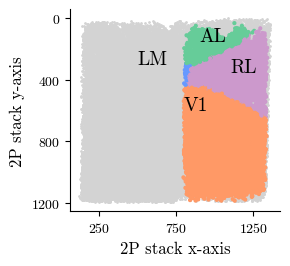

In [47]:
# Query the coregistration table to get the matched (functional-structural) neurons 
matched_df = pd.DataFrame(client.materialize.query_table('coregistration_manual_v4', return_df=False))  # type: ignore
matched_df = matched_df[matched_df['pt_root_id'] != 0]  # Remove neurons with a pt_root_id = 0 (not matched)
print('Number of matched neurons:', len(matched_df['pt_root_id'].unique()))

# Collect the spatial data of all the in the dataset 
area, x, y, z, unit_id, scan_idx, session = (nda.AreaMembership * nda.StackUnit).fetch('brain_area', 'stack_x', 'stack_y', 'stack_z', 'unit_id', 'scan_idx', 'session')
coord_df = pd.DataFrame({'unit_id': unit_id, 'scan_idx': scan_idx, 'session': session, 'stack_x': x, 'stack_y': y, 'stack_z': z, 'brain_area': area})
coord_df.shape
matched_df = matched_df.merge(coord_df, on=['unit_id', 'scan_idx', 'session'], how='left')

fig, ax = plot_brain_area(matched_df['stack_x'], matched_df['stack_y'], matched_df['brain_area'], figsize=(3, 3))
ax.scatter(coord_df['stack_x'], coord_df['stack_y'], color='lightgray', s=1, zorder=0)
plt.show()

## Proofread Neurons

In [48]:
# Neurons with proofread of the axon
proof_raw = client.materialize.query_table(   # type: ignore
    table="proofreading_status_and_strategy",
    filter_equal_dict={"status_axon": True},
    desired_resolution=[1, 1, 1],
    split_positions=True,
    return_df=False
) 

proof_df = pd.DataFrame(proof_raw)
proof_df = proof_df[proof_df['pt_root_id'] != 0]

# Keep root_id
proof_root_ids = proof_df["pt_root_id"].dropna().unique().tolist()
print(f"Found {len(proof_root_ids)} proofread neurons")

#syn_df_proof = fetch_synapses(proof_root_ids, client, neur_to_load=100, max_retries=5) 
#syn_df_proof.to_pickle('/notebooks/workspace/data/synaptic_df_proof_1412.pkl')

Found 1982 proofread neurons


Fitted parameters: sigma=0.612, mu=3.93, loc=0


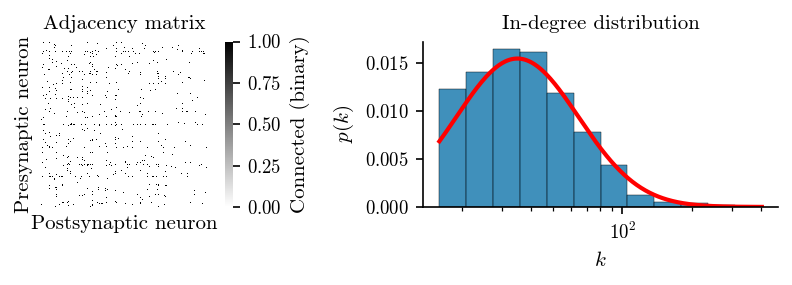

In [50]:
# Upload the synaptic data for the proofread neurons
syn_df_proof = pd.read_pickle('/notebooks/workspace/data/synaptic_df_proof_1412.pkl')

# Remove self-connections (autapses): keep only synapses where pre != post
syn_df_used = syn_df_proof.query("pre_pt_root_id != post_pt_root_id")

# For each (presynaptic, postsynaptic) neuron pair, set 1 if there is at least one synapse (sum(size) > 0), else 0 
# (see: https://tutorial.microns-explorer.org/quickstart_notebooks/04-cave-query-synapses.html )
syn_mat_proof = syn_df_used.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id", values="size", aggfunc=lambda x: float(np.sum(x) > 0)).fillna(0)
syn_mat_proof = syn_mat_proof.reindex(columns=np.array(syn_mat_proof.index)).fillna(0)

# Create the adjacency matrix
adj_mat_proof = syn_mat_proof.values 

# Compute in-degree and out-degree for each neuron
degree_df_proof = pd.DataFrame({
    'pt_root_id': syn_mat_proof.index,
    'in_degree': syn_mat_proof.sum(axis=0).values,   
    'out_degree': syn_mat_proof.sum(axis=1).values   
})

# Plot adjacency matrix and degree distribution 
fig, ax = plt.subplots(1, 2, figsize=(6, 2), dpi=150)

# Adjacency matrix
sns.heatmap(
    syn_mat_proof,
    cmap="gray_r",
    square=True,
    xticklabels=False,
    yticklabels=False,
    cbar_kws={"label": "Connected (binary)"},
    ax=ax[0]
)
ax[0].set_title("Adjacency matrix")
ax[0].set_xlabel("Postsynaptic neuron")
ax[0].set_ylabel("Presynaptic neuron")

# Degree distribution
degrees = degree_df_proof["in_degree"].to_numpy(dtype=float)
data = degrees[degrees > 15]

# Fit lognormal (loc fixed to 0)
sigma, loc, scale = lognorm.fit(data, floc=0)
print(f"Fitted parameters: sigma={sigma:.3g}, mu={np.log(scale):.3g}, loc={loc:.3g}")

xmin, xmax = data.min(), data.max()
x = np.logspace(np.log10(xmin), np.log10(xmax), 300)
bins = np.logspace(np.log10(xmin), np.log10(xmax), 13)

sns.histplot(data, bins=bins, stat="density", edgecolor="black", ax=ax[1])
ax[1].plot(x, lognorm.pdf(x, sigma, loc=loc, scale=scale), "r-", lw=2)
ax[1].set_xscale("log")
ax[1].set_xlabel(r"$k$")
ax[1].set_ylabel(r"$p(k)$")
ax[1].set_title("In-degree distribution")

plt.tight_layout()
plt.show()

## Data vs Erdős-Rényi

In [ ]:
def dyad_counts(A):
    """
    Count dyad types (pairs of neurons) in a directed network.
    """
    N = A.shape[0]  # number of nodes
    iu = np.triu_indices(N, 1)  # indices for unordered pairs (i < j)

    # Get edges in both directions for each pair
    aij = A[iu]        # edge i -> j
    aji = A.T[iu]      # edge j -> i
    s = aij + aji      # possible values: 0 (none), 1 (uni), 2 (recip)

    # Count each dyad type
    none  = int(np.sum(s == 0))  # no connection
    uni   = int(np.sum(s == 1))  # one-direction connection
    recip = int(np.sum(s == 2))  # bidirectional connection

    n_pairs = N * (N - 1) // 2   # total unordered pairs
    p_conn = float(A.sum() / (N * (N - 1)))  # directed edge density

    return {
        "N": N,
        "n_pairs": n_pairs,
        "p_conn": p_conn,
        "none": none,
        "uni": uni,
        "recip": recip
    }


def compute_r(A):
    """
    Compute reciprocity correlation (r)
    """
    obs = dyad_counts(A)
    p = obs["p_conn"]  # directed connection probability
    recip_frac = obs["recip"] / obs["n_pairs"]  # fraction of reciprocal pairs

    # Avoid division by zero
    if p <= 0 or p >= 1:
        r = np.nan
    else:
        r = (recip_frac - p**2) / (p * (1 - p))

    return r, recip_frac, p


def er_null_dyad_counts(N, p_conn, M=10000, seed=None):
    """
    Simulate M directed ER graphs with edge probability p_conn.
    Count dyad types in each simulation.
    """
    rng = np.random.default_rng(seed)
    iu = np.triu_indices(N, 1)

    none = np.empty(M, dtype=int)
    uni  = np.empty(M, dtype=int)
    recip = np.empty(M, dtype=int)

    for m in range(M):
        # Generate random directed graph
        A_rand = (rng.random((N, N)) < p_conn).astype(np.int8)
        np.fill_diagonal(A_rand, 0)  # remove self-loops

        # Extract dyad types
        aij = A_rand[iu]
        aji = A_rand.T[iu]
        s = aij + aji

        none[m]  = np.sum(s == 0)
        uni[m]   = np.sum(s == 1)
        recip[m] = np.sum(s == 2)

    return none, uni, recip


def compute_p_value_two_sided(obs_value, null_values):
    """
    Two-sided p-value (no finite-sample correction):
    2 * min(P(null >= obs), P(null <= obs))
    """
    null_values = np.asarray(null_values)
    p_over = np.mean(null_values >= obs_value)
    p_under = np.mean(null_values <= obs_value)
    return float(min(2 * min(p_over, p_under), 1.0))


def compute_dyad_stats_vs_er(A, M=10000, seed=None):
    """
    Compare observed dyad counts to ER null model.
    Returns observed counts, null distributions,
    and two-sided p-values only.
    """
    rng = np.random.default_rng(seed)

    # Observed network
    obs = dyad_counts(A)

    # Simulate ER null model
    none_null, uni_null, recip_null = er_null_dyad_counts(
        obs["N"], obs["p_conn"], M=M, seed=rng
    )

    # Two-sided p-values
    p_two = {
        "none":  compute_p_value_two_sided(obs["none"],  none_null),
        "uni":   compute_p_value_two_sided(obs["uni"],   uni_null),
        "recip": compute_p_value_two_sided(obs["recip"], recip_null),
    }

    null_arrays = (none_null, uni_null, recip_null)

    return obs, null_arrays, p_two

In [63]:
r, recip_frac, p = compute_r(adj_mat_proof)
print(f"Reciprocity correlation (r): {r:.3f}")

obs, null_arrays, p_two = compute_dyad_stats_vs_er(adj_mat_proof, M=10000)
print("Observed:", obs)
print("Two-sided p-values:", p_two)

Reciprocity correlation (r): 0.197
Observed: {'N': 1965, 'n_pairs': 1929630, 'p_conn': 0.02667143442007017, 'none': 1837922, 'uni': 80484, 'recip': 11224}
Two-sided p-values: {'none': 0.0, 'uni': 0.0, 'recip': 0.0}


## Panel Microns Data

In [86]:
meta_df = matched_df[['pt_root_id', 'session', 'scan_idx', 'unit_id', 'residual', 'score', 'stack_x', 'stack_y', 'stack_z', 'brain_area']].copy()
meta_degree_df = pd.merge(meta_df, degree_df_proof, on='pt_root_id', how='inner')

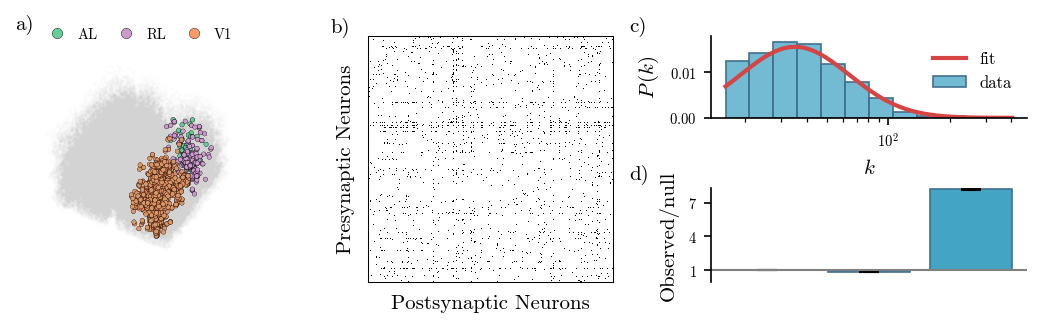

In [89]:
# Create the full figure
fig = plt.figure(figsize=(18/2.54, 5/2.54), dpi=150, constrained_layout=False)

# Colors
my_palette = my_palettes["10"]
area_colors = {"AL": "#66CC99", "RL": "#CC99CC", "V1": "#FF9966"}

# Font sizes
tick_fontsize = 7
panel_label_kw = dict(fontsize=10, fontweight="bold", va="top", ha="left")

# Layout: left to right panels a, b, then a right column with c on top and d below
gs = gridspec.GridSpec(
    nrows=1, ncols=3,
    figure=fig,
    width_ratios=[1.0, 1.0, 1.20],
    wspace=0.32
)
gs_right = gs[0, 2].subgridspec(
    nrows=2, ncols=1,
    height_ratios=[1.0, 1.15],
    hspace=0.8
)

# Panel a: 3D scatter of coordinates, highlight selected brain areas
ax_a = fig.add_subplot(gs[0, 0], projection="3d")

meta_plot = meta_degree_df[meta_degree_df["brain_area"] != "LM"].copy()

ax_a.scatter(
    coord_df["stack_x"], coord_df["stack_y"], coord_df["stack_z"],
    c="lightgray", s=0.6, alpha=0.004, depthshade=False
)
ax_a.scatter(
    meta_plot["stack_x"], meta_plot["stack_y"], meta_plot["stack_z"],
    c=[area_colors[a] for a in meta_plot["brain_area"]],
    s=5, alpha=1.0, depthshade=False,
    edgecolors="k", linewidths=0.2
)

# Clean 3D axes and set view
ax_a.set_xticks([])
ax_a.set_yticks([])
ax_a.set_zticks([])
ax_a.invert_yaxis()
ax_a.view_init(elev=45, azim=-60)
ax_a.set_axis_off()

# Legend for highlighted areas
legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor=area_colors[k],
        markeredgecolor="k",
        markeredgewidth=0.2,
        markersize=5,
        label=k
    )
    for k in ["AL", "RL", "V1"]
]
ax_a.legend(
    handles=legend_handles,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.06),
    ncol=3,
    fontsize=7,
    handletextpad=0.4,
    columnspacing=0.9,
    borderaxespad=0.0
)

# Panel b: adjacency matrix heatmap, no colorbar
ax_b = fig.add_subplot(gs[0, 1])

sns.heatmap(
    adj_mat_proof[:250, :250],
    cmap="gray_r",
    square=True,
    xticklabels=False,
    yticklabels=False,
    cbar=False,
    ax=ax_b
)

ax_b.set_xlabel("Postsynaptic Neurons", labelpad=6)
ax_b.set_ylabel("Presynaptic Neurons", labelpad=6)

# Show a thin frame around the heatmap
for spine in ax_b.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
    spine.set_color("black")

ax_b.tick_params(labelsize=tick_fontsize)

# Panel c: in degree distribution on log x axis with lognormal fit
ax_c = fig.add_subplot(gs_right[0, 0])

degrees = degree_df_proof["in_degree"].to_numpy(dtype=float)
data = degrees[degrees > 15]

sigma, loc, scale = lognorm.fit(data, floc=0)

xmin, xmax = data.min(), data.max()
x = np.logspace(np.log10(xmin), np.log10(xmax), 300)
bins = np.logspace(np.log10(xmin), np.log10(xmax), 13)

sns.histplot(
    data,
    bins=bins,
    stat="density",
    color=my_palette[2],
    edgecolor=my_palette[3],
    linewidth=0.8,
    ax=ax_c,
    label="data"
)
ax_c.plot(
    x,
    lognorm.pdf(x, sigma, loc=loc, scale=scale),
    color=my_palette[0],
    lw=2,
    label="fit"
)

ax_c.set_xlabel(r"$k$")
ax_c.set_ylabel(r"$P\,(k)$")
ax_c.set_xscale("log")
ax_c.legend(fontsize=8, frameon=False, loc="upper right")
ax_c.tick_params(labelsize=tick_fontsize)
ax_c.margins(y=0.08)

# Panel d: dyad counts compared to ER null model, show mean and standard deviation
ax_d = fig.add_subplot(gs_right[1, 0])

none_null, uni_null, recip_null = null_arrays

obs_vec = np.array([obs["none"], obs["uni"], obs["recip"]], dtype=float)
mean_vec = np.array([none_null.mean(), uni_null.mean(), recip_null.mean()], dtype=float)
std_vec = np.array([none_null.std(ddof=1), uni_null.std(ddof=1), recip_null.std(ddof=1)], dtype=float)

ratio = obs_vec / mean_vec
ratio_err = std_vec / mean_vec

labels = ["none", "uni", "recip"]
xpos = np.arange(len(labels))

baseline = 1.0
heights = ratio - baseline

bars = ax_d.bar(
    xpos,
    heights,
    bottom=baseline,
    color=my_palette[2],
    edgecolor=my_palette[3],
    linewidth=0.8
)

ax_d.errorbar(
    xpos,
    ratio,
    yerr=ratio_err,
    fmt="none",
    ecolor="black",
    capsize=5,
    lw=1.0
)

ax_d.axhline(baseline, color="gray", lw=1)

ax_d.set_xticks([])
ax_d.set_xlabel("")
ax_d.spines["bottom"].set_visible(False)

ax_d.set_ylabel("Observed/null")
ax_d.set_yticks([1, 4, 7])

top = (ratio + ratio_err).max() + 0.1
bottom = min(0.0, (ratio - ratio_err).min() - 0.2)
ax_d.set_ylim(bottom, max(top, 5.2))

ax_d.spines["top"].set_visible(False)
ax_d.spines["right"].set_visible(False)
ax_d.tick_params(labelsize=tick_fontsize)
ax_d.margins(y=0.15)

# Panel labels
ax_a.text2D(0.0, 1.09, "a)", transform=ax_a.transAxes, **panel_label_kw)
ax_b.text(-0.15, 1.08, "b)", transform=ax_b.transAxes, **panel_label_kw)  # type: ignore
ax_c.text(-0.26, 1.25, "c)", transform=ax_c.transAxes, **panel_label_kw)  # type: ignore
ax_d.text(-0.26, 1.25, "d)", transform=ax_d.transAxes, **panel_label_kw)  # type: ignore

# Final margins and show
fig.subplots_adjust(left=0.03, right=0.99, top=0.97, bottom=0.14)
plt.savefig("/notebooks/workspace/figures/panel_microns.png", dpi=500, bbox_inches="tight")
plt.show()

## Functional Data

In [51]:
# Filter matched_df to include only relevant columns
meta_df = matched_df[['pt_root_id', 'session', 'scan_idx', 'unit_id', 'residual', 'score', 'stack_x', 'stack_y', 'brain_area']].copy()
meta_degree_df = pd.merge(meta_df, degree_df_proof, on='pt_root_id', how='inner')

# Get scan info
scan_keys = meta_degree_df[['session', 'scan_idx']].drop_duplicates().to_dict(orient='records')   # type:ignore
scan_info_map = {}
fps_records = []

for scan_key in scan_keys:
    stimuli_df = pd.DataFrame((nda.Trial & scan_key).fetch())
    stim_info, fps, nframes = merge_consecutive_stimuli(stimuli_df, scan_key)

    session = scan_key['session']
    scan_idx = scan_key['scan_idx']
    scan_info_map[(session, scan_idx)] = (stim_info, nframes, fps)
    fps_records.append({'session': session, 'scan_idx': scan_idx, 'fps': fps})

fps_df = pd.DataFrame(fps_records)
# Merge the fps information into the meta_degree_df
meta_degree_df = pd.merge(meta_degree_df, fps_df, on=['session', 'scan_idx'])

In [52]:
# Filter for a specific fps
target_fps = 6.3009
meta_degree_df_filtered = meta_degree_df[np.isclose(meta_degree_df['fps'], target_fps, rtol=1e-1)].reset_index(drop=True)

# Extract traces for the filtered neurons
trace_results = []
min_len = float('inf')

choosen_df = meta_degree_df_filtered
for _, row in tqdm(choosen_df.iterrows(), total=len(choosen_df), desc="Extracting traces"):
    stim_info, nframes, fps = scan_info_map[(row['session'], row['scan_idx'])]
    result = get_traces(row, stim_info, nframes, fps, rest_offset=100, rest_period='end')

    if result['calcium_trace'] is not None and result['spike_trace'] is not None:
        trace_len = len(result['calcium_trace'])
        min_len = min(min_len, trace_len)

    trace_results.append(result)

# Trim traces to the minimum length
trimmed_results = []
for res in trace_results:
    if res['calcium_trace'] is not None and res['spike_trace'] is not None:
        res['calcium_trace'] = res['calcium_trace'][-min_len:]
        res['spike_trace'] = res['spike_trace'][-min_len:]
        res['resting_time_axis'] = res['resting_time_axis'][-min_len:]
        trimmed_results.append(res)

trace_df = pd.DataFrame(trimmed_results)
key_cols = trace_df['key'].apply(pd.Series)
trace_df = pd.concat([trace_df.drop(columns='key'), key_cols], axis=1)

trace_df = trace_df[['pt_root_id', 'session', 'scan_idx', 'unit_id', 'calcium_trace', 'spike_trace', 'resting_time_axis']]
# Merge the filtered metadata with the trace data
final_df = pd.merge(choosen_df, trace_df, on=['pt_root_id','session','scan_idx','unit_id'], how='inner')

print(f"Neurons with valid traces: {len(final_df)}")

Extracting traces: 100%|██████████| 1089/1089 [00:16<00:00, 67.31it/s]


Neurons with valid traces: 1089


In [42]:
final_df['hwhm'] = final_df.apply(lambda row: compute_trace_hwhm(row, trace_type="calcium", maxlag=300), axis=1)
final_df.to_pickle('/notebooks/workspace/data/data_proof_1412.pkl')

# Compute in-degree-hwhm correlation
rho, pval = spearmanr(final_df['in_degree'], final_df['hwhm'])
print(f"Spearman correlation between in-degree and HWHM: rho={rho:.3f}, p-value={pval:.3e}")

Spearman correlation between in-degree and HWHM: rho=0.164, p-value=4.803e-08
